In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("phase 2 data.csv")
df

,Index,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,0,0.0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1,1,0.0,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,...,0,1,1,0,0,0,0,0,0,0
2,2,0.0,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,3,0.0,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,4,0.0,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,253675,0.0,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,1,0
253676,253676,2.0,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,253677,0.0,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,...,1,0,0,1,0,0,0,0,0,0
253678,253678,0.0,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,0,0,0,0


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = df.drop(columns=["Diabetes_012","Index"])
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
1,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,1.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,1.0,1.0,...,0,1,0,0,0,0,0,0,1,0
253676,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,1.0,0.0,...,1,0,0,1,0,0,0,0,0,0
253678,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,0


In [5]:
y = df["Diabetes_012"]
DT = DecisionTreeClassifier()
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [8]:
Precision = []
Recall = []
F1 = []
Accuracy = []
AUC = []
for train_indexes, test_indexes in KFold(n_splits=10, shuffle=True).split(X):
    X_train, X_test = X.iloc[train_indexes], X.iloc[test_indexes]
    y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]
    DT.fit(X_train, y_train)
    y_pred = DT.predict(X_test)
    y_pred_proba = DT.predict_proba(X_test)
    Precision.append(precision_score(y_test, y_pred, average=None))
    Recall.append(recall_score(y_test, y_pred, average=None))
    F1.append(f1_score(y_test, y_pred, average=None))
    Accuracy.append(accuracy_score(y_test, y_pred))
    AUC.append(roc_auc_score(y_test, y_pred_proba, multi_class="ovr"))

Precision, Recall, F1, Accuracy, AUC

([array([0.87198824, 0.02025783, 0.29484095]),
  array([0.87163669, 0.02631579, 0.29288591]),
  array([0.87346147, 0.03454894, 0.30432447]),
  array([0.87706553, 0.02304965, 0.30181624]),
  array([0.8786311 , 0.01901141, 0.29570747]),
  array([0.87576404, 0.05350554, 0.29293201]),
  array([0.87562541, 0.0210728 , 0.29180328]),
  array([0.87265581, 0.03157895, 0.30200978]),
  array([0.87758678, 0.02101576, 0.30353261]),
  array([0.87445867, 0.03141361, 0.28979376])],
 [array([0.86209322, 0.02401747, 0.3077567 ]),
  array([0.86271194, 0.03246753, 0.30179806]),
  array([0.86530976, 0.03964758, 0.315511  ]),
  array([0.86325186, 0.02801724, 0.32221272]),
  array([0.86318489, 0.02320186, 0.31958763]),
  array([0.86304632, 0.06041667, 0.31394009]),
  array([0.86561523, 0.0230608 , 0.30867052]),
  array([0.8656457 , 0.03896104, 0.3072672 ]),
  array([0.86545556, 0.02505219, 0.32134638]),
  array([0.85968934, 0.0387931 , 0.31048159])],
 [array([0.8670125 , 0.02197802, 0.30116041]),
  array([0.

In [9]:
Precision = np.array(Precision)
Recall = np.array(Recall)
F1 = np.array(F1)
Accuracy = np.array(Accuracy)
AUC = np.array(AUC)

In [10]:
Diabetes_0_Precision = Precision[:, 0].mean()
Diabetes_1_Precision = Precision[:, 1].mean()
Diabetes_2_Precision = Precision[:, 2].mean()
Diabetes_0_Recall = Recall[:, 0].mean()
Diabetes_1_Recall = Recall[:, 1].mean()
Diabetes_2_Recall = Recall[:, 2].mean()
Diabetes_0_F1 = F1[:, 0].mean()
Diabetes_1_F1 = F1[:, 1].mean()
Diabetes_2_F1 = F1[:, 2].mean()
Diabetes_Accuracy = Accuracy.mean()
Diabetes_AUC = AUC.mean()
Diabetes_0_Precision, Diabetes_1_Precision, Diabetes_2_Precision, Diabetes_0_Recall, Diabetes_1_Recall, Diabetes_2_Recall, Diabetes_0_F1, Diabetes_1_F1, Diabetes_2_F1, Diabetes_Accuracy, Diabetes_AUC

(0.8748873723880444,
 0.02817702666787832,
 0.29696464707849884,
 0.8636003828896252,
 0.033363547212524367,
 0.3128571880889609,
 0.8692050637228725,
 0.03053912157992838,
 0.3046772694136081,
 0.7717005676442763,
 0.567034134378498)

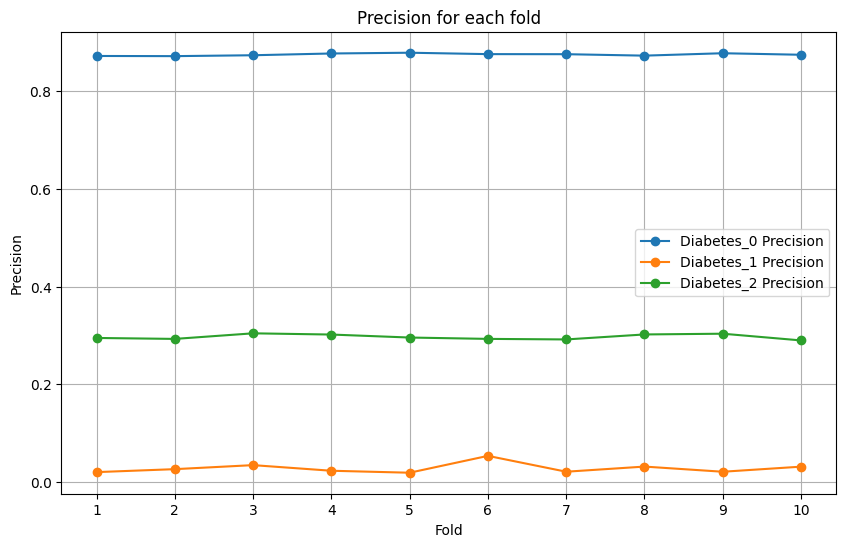

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), Precision[:, 0], marker='o', label='Diabetes_0 Precision')
plt.plot(range(1, 11), Precision[:, 1], marker='o', label='Diabetes_1 Precision')
plt.plot(range(1, 11), Precision[:, 2], marker='o', label='Diabetes_2 Precision')
plt.title('Precision for each fold')
plt.xlabel('Fold')
plt.ylabel('Precision')
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show() 

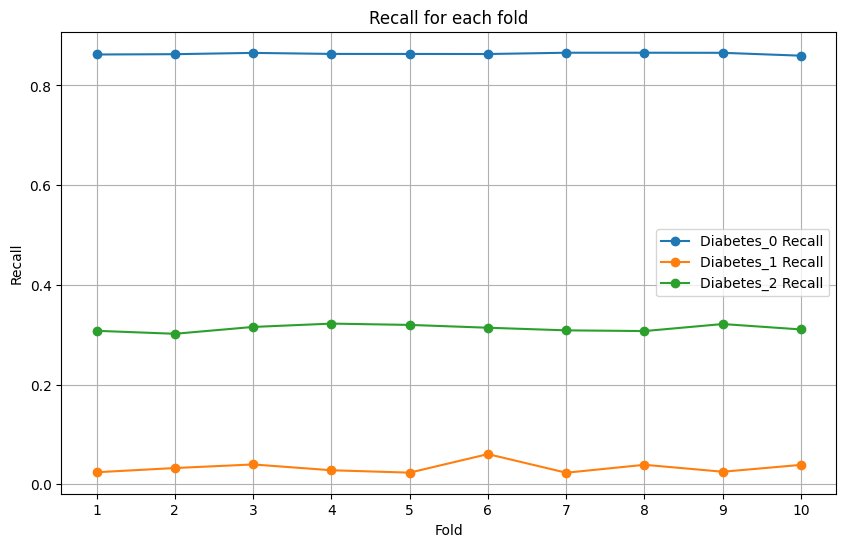

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), Recall[:, 0], marker='o', label='Diabetes_0 Recall')
plt.plot(range(1,11), Recall[:, 1], marker='o', label="Diabetes_1 Recall")
plt.plot(range(1,11), Recall[:, 2], marker='o', label="Diabetes_2 Recall")
plt.title("Recall for each fold")
plt.xlabel("Fold")
plt.ylabel("Recall")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

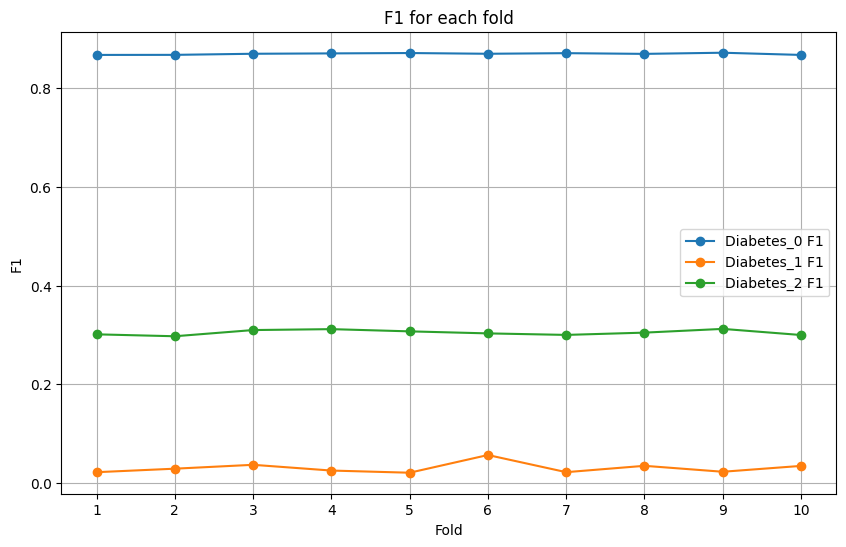

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), F1[:, 0], marker='o', label='Diabetes_0 F1')
plt.plot(range(1,11), F1[:, 1], marker='o', label='Diabetes_1 F1')
plt.plot(range(1,11), F1[:, 2], marker='o', label='Diabetes_2 F1')
plt.title("F1 for each fold")
plt.xlabel("Fold")
plt.ylabel("F1")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

In [ ]:
Diabetes_Dict = {
    "Diabetes_0_Precision": Diabetes_0_Precision,
    "Diabetes_1_Precision": Diabetes_1_Precision,
    "Diabetes_2_Precision": Diabetes_2_Precision,
    "Diabetes_0_Recall": Diabetes_0_Recall,
    "Diabetes_1_Recall": Diabetes_1_Recall,
    "Diabetes_2_Recall": Diabetes_2_Recall,
    "Diabetes_0_F1": Diabetes_0_F1,
    "Diabetes_1_F1": Diabetes_1_F1,
    "Diabetes_2_F1": Diabetes_2_F1,
    "Diabetes_Accuracy": Diabetes_Accuracy,
    "Diabetes_AUC": Diabetes_AUC
}

Diabetes_Frame = pd.DataFrame(Diabetes_Dict, index=[0])
Diabetes_Frame.to_csv("Diabetes_Results_MLP.csv", index=False)
Diabetes_Frame

,Diabetes_0_Precision,Diabetes_1_Precision,Diabetes_2_Precision,Diabetes_0_Recall,Diabetes_1_Recall,Diabetes_2_Recall,Diabetes_0_F1,Diabetes_1_F1,Diabetes_2_F1,Diabetes_Accuracy,Diabetes_AUC
0,0.874887,0.028177,0.296965,0.8636,0.033364,0.312857,0.869205,0.030539,0.304677,0.771701,0.567034


: 